In [1]:
# Imports
from pathlib import Path
import csv
import os
import uproot
import awkward as ak
import vector
import pandas as pd
import numpy as np

vector.register_awkward()

In [2]:
TARGET_PHYSICS_SHORT = {
    # Multijet
    "Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ0WithSW", "Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ1WithSW",
    "Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ2WithSW", "Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ3WithSW",
    "Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ4WithSW", "Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ5WithSW",
    "Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ6WithSW", "Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ7WithSW",
    "Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ8WithSW", "Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ9WithSW",
    "Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ10WithSW", "Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ11WithSW",
    "Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ12WithSW",
}

In [3]:
mc_metadata = {}

with open("../metadata.csv", mode="r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        p_short = row["physics_short"]
        
        # SKIP if it's not in our target list
        if p_short not in TARGET_PHYSICS_SHORT:
            continue
            
        
        mc_metadata[p_short] = {
            "physics_short": p_short,
            "crossSection_pb": float(row.get("crossSection_pb", 0)),
            "genFiltEff": float(row.get("genFiltEff", 1.0)),
            "kFactor": float(row.get("kFactor", 1.0)),
            "nEvents": float(row.get("nEvents", 0)),
            "sumOfWeights": float(row.get("sumOfWeights", 0)),
            "sumOfWeightsSquared": float(row.get("sumOfWeightsSquared", 0)),
            "process": row.get("process", ""),
            "description": row.get("description", "")
        }

In [4]:
MC_BASE_PATH = Path("/home/aegis/ether/Research_HEP/NRAD_Dataset/MC/reduce_root")
METADATA_FILE_OUT = Path("metadata_processed_susy.csv")

LUMINOSITY = 138 # fb^-1

def count_actual_events(sub_path: Path) -> int:
    num_events = 0
    sum_weights = 0
    sum_weights_squared = 0
    for file in os.listdir(sub_path):
        if file.endswith(".root"): 
            file_path = f"{sub_path}/{file}"
            try:
                tree = uproot.open(f"{file_path}:CollectionTree")
                num_events += tree.num_entries
                print(f"File: {file_path} | Events: {tree.num_entries}")
                # Fetch the array, grab the 0th index (nominal weight), and sum it
                weights = tree["EventInfoAuxDyn_mcEventWeights"].array()

                sum_weights += ak.sum(weights[:, 0])
                sum_weights_squared += ak.sum(weights[:, 0]**2)
                
            except Exception as e:
                print(f"Error reading {file_path}: {e}")
    return num_events, sum_weights, sum_weights_squared



def analyze_process(mc_process):
    """
    Calculate the scale factor for each subprocesses of the MC process
    """
    print(f"\n--- Analyzing MC process {mc_process} ---")

    # Check if all these subprocesses exist in my dataset
    process_sub = [sub.replace("mc20_13TeV_MC_", "") for sub in os.listdir(f"{MC_BASE_PATH}/{mc_process}")]
    print(process_sub)

    for sub in process_sub:
        # Check if within the list of sub
        if sub not in mc_metadata:
            print(sub, "not in the list")
            continue

        sub_path = f"{MC_BASE_PATH}/{mc_process}/mc20_13TeV_MC_{sub}"

        num_events, sum_of_weights, sum_of_weights_squared = count_actual_events(sub_path)
        

        sum_weights_global = mc_metadata[sub]["sumOfWeights"]
        print("="*50)
        print(f"{sub} has {num_events} total events")
        
        print("Calculating Scale Factor...")
        # get cross section
        xsec_pb = mc_metadata[sub]["crossSection_pb"]
        genFilt = mc_metadata[sub]["genFiltEff"]
        kFactor = mc_metadata[sub]["kFactor"]
        xsec_pb = xsec_pb * genFilt * kFactor
        print(f"{sub} has a {xsec_pb} pb cross section")
        xsec_fb = xsec_pb *1000
        print(f"Cross section in fb: {xsec_fb}")
        

        # scale_factor_ngen = xsec_fb*LUMINOSITY/num_events
        scale_factor_sub_weight = xsec_fb*LUMINOSITY/sum_of_weights
        scale_factor_tot_weight = xsec_fb*LUMINOSITY/sum_weights_global
        # print(f"Subprocess {sub} has {scale_factor_ngen} scale factor, using N generated method")
        print(f"Subprocess {sub} has {scale_factor_sub_weight} scale factor, using partial sum of weights method")
        print(f"Subprocess {sub} has {scale_factor_tot_weight} scale factor, using global sum of weights method")

        mc_metadata[sub]["nEvents_pros"] = num_events
        mc_metadata[sub]["sum_w_pros"] = sum_of_weights
        mc_metadata[sub]["sum_w_squared_pos"] = sum_of_weights_squared
        mc_metadata[sub]["scale_factor_sub_weight"] = scale_factor_sub_weight
        mc_metadata[sub]["scale_factor_tot_weight"] = scale_factor_tot_weight
        mc_metadata[sub]["luminosity"] = LUMINOSITY
 
def save_new_metadata():
    fieldnames = [
        "physics_short", "crossSection_pb", "genFiltEff", 
        "kFactor", "nEvents", "sumOfWeights", "sumOfWeightsSquared", 
        "process", "description", 
        "nEvents_pros", "sum_w_pros", "sum_w_squared_pos", 
        "scale_factor_sub_weight", "scale_factor_tot_weight", "luminosity" 
    ] # Removed dataset_number since you didn't load it, added both scale factors
    
    with open(METADATA_FILE_OUT, mode="w", encoding="utf-8", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        
        for p_short, data in mc_metadata.items():
            # Check for a key we actually created!
            if "scale_factor_sub_weight" in data: 
                writer.writerow(data)
                
    print(f"\n✅ Successfully saved processed metadata to {METADATA_FILE_OUT}")


In [5]:
from matplotlib.pylab import save



save_metadata = False
if save_metadata == True:
    mc_processes = ["Multijet"]
# mc_processes = ["Diboson"]
    for mc_proc in mc_processes:
        analyze_process(mc_proc)
    
    save_new_metadata()

/home/aegis/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


### Analysis

In [6]:
mc_process_list = {
    "Wjets": [
        "mc20_13TeV_MC_Sh_2211_Wtaunu_L_maxHTpTV2_BFilter_file_index.json",
        "mc20_13TeV_MC_Sh_2211_Wtaunu_L_maxHTpTV2_CFilterBVeto_file_index.json",
        "mc20_13TeV_MC_Sh_2211_Wtaunu_L_maxHTpTV2_CVetoBVeto_file_index.json",
        "mc20_13TeV_MC_Sh_2211_Wtaunu_H_maxHTpTV2_BFilter_file_index.json",
        "mc20_13TeV_MC_Sh_2211_Wtaunu_H_maxHTpTV2_CFilterBVeto_file_index.json",
        "mc20_13TeV_MC_Sh_2211_Wtaunu_H_maxHTpTV2_CVetoBVeto_file_index.json",
    ],
    "Zjets": [
        "mc20_13TeV_MC_Sh_2211_Zmumu_maxHTpTV2_BFilter_file_index.json",
        "mc20_13TeV_MC_Sh_2211_Zmumu_maxHTpTV2_CFilterBVeto_file_index.json",
        "mc20_13TeV_MC_Sh_2211_Zmumu_maxHTpTV2_CVetoBVeto_file_index.json",
        "mc20_13TeV_MC_Sh_2211_Znunu_pTV2_BFilter_file_index.json",
        "mc20_13TeV_MC_Sh_2211_Znunu_pTV2_CFilterBVeto_file_index.json",
        "mc20_13TeV_MC_Sh_2211_Znunu_pTV2_CVetoBVeto_file_index.json",
        "mc20_13TeV_MC_Sh_2214_Ztautau_maxHTpTV2_CFilterBVeto_file_index.json",
        "mc20_13TeV_MC_Sh_2214_Ztautau_maxHTpTV2_CVetoBVeto_file_index.json",
    ],
    "ttbar": [
        "mc20_13TeV_MC_PhPy8EG_A14_ttbar_hdamp258p75_nonallhad_file_index.json",
        "mc20_13TeV_MC_PhPy8EG_A14_ttbar_hdamp258p75_allhad_file_index.json",
    ],
    "Single_top": [
        "mc20_13TeV_MC_PowhegPythia8EvtGen_A14_singletop_schan_lept_top_file_index.json",
        "mc20_13TeV_MC_PowhegPythia8EvtGen_A14_singletop_schan_lept_antitop_file_index.json",
        "mc20_13TeV_MC_PhPy8EG_A14_tchan_BW50_lept_top_file_index.json",
        "mc20_13TeV_MC_PhPy8EG_A14_tchan_BW50_lept_antitop_file_index.json",
    ],
    "Multijet": [
        "mc20_13TeV_MC_Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ0WithSW_file_index.json",
        "mc20_13TeV_MC_Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ1WithSW_file_index.json",
        "mc20_13TeV_MC_Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ2WithSW_file_index.json",
        "mc20_13TeV_MC_Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ3WithSW_file_index.json",
        "mc20_13TeV_MC_Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ4WithSW_file_index.json",
        "mc20_13TeV_MC_Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ5WithSW_file_index.json",
        "mc20_13TeV_MC_Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ6WithSW_file_index.json",
        "mc20_13TeV_MC_Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ7WithSW_file_index.json",
        "mc20_13TeV_MC_Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ8WithSW_file_index.json",
        "mc20_13TeV_MC_Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ9WithSW_file_index.json",
        "mc20_13TeV_MC_Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ10WithSW_file_index.json",
        "mc20_13TeV_MC_Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ11WithSW_file_index.json",
        "mc20_13TeV_MC_Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ12WithSW_file_index.json",
    ],
    "Diboson": [
        "mc20_13TeV_MC_Sh_2211_WlvZqq_file_index.json",
        "mc20_13TeV_MC_Sh_2211_WqqZvv_file_index.json",
        "mc20_13TeV_MC_Sh_2211_ZqqZvv_file_index.json",
        "mc20_13TeV_MC_Sh_2211_WlvWqq_file_index.json",
    ],
}

In [7]:
import time
import glob
import datetime

PROCESSED_METADATA_CSV = "metadata_processed_susy.csv"

def load_scale_factors(csv_path):
    """Loads the pre-calculated scale factors from the processed metadata CSV."""
    sf_dict = {}
    if not os.path.exists(csv_path):
        print(f"Error: Could not find {csv_path}. Please run your metadata script first.")
        exit(1)
        
    with open(csv_path, mode="r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            p_short = row["physics_short"]
            # We use the total weight scale factor as is standard for ATLAS MC weighting
            sf_dict[p_short] = float(row["scale_factor_sub_weight"])
            
    print(f"Loaded scale factors for {len(sf_dict)} subprocesses from {csv_path}")
    return sf_dict

mc_scale_factors = load_scale_factors(PROCESSED_METADATA_CSV)

Loaded scale factors for 13 subprocesses from metadata_processed_susy.csv


In [8]:
mc_scale_factors

{'Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ0WithSW': 349530370.0,
 'Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ1WithSW': 8759428.0,
 'Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ2WithSW': 297976770.0,
 'Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ3WithSW': 198810990.0,
 'Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ4WithSW': 69980040.0,
 'Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ5WithSW': 189731780.0,
 'Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ6WithSW': 673065900.0,
 'Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ7WithSW': 359657500.0,
 'Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ8WithSW': 26322190.0,
 'Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ9WithSW': 6322729.0,
 'Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ10WithSW': 134832.11,
 'Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ11WithSW': 9190.911,
 'Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ12WithSW': 49.909832}

In [9]:

# ------------------ PHYSICS FUNCTIONS ------------------
def delta_R(obj1, obj2):
    """Custom Delta R calculation compatible with Awkward Arrays."""
    deta = obj1.eta - obj2.eta
    dphi = np.abs(obj1.phi - obj2.phi)
    
    # Handle wrap-around for angles greater than pi
    dphi = ak.where(dphi > np.pi, 2 * np.pi - dphi, dphi)
    
    return np.sqrt(deta**2 + dphi**2)
 

def phys_object_reconstruction(filepath):
    """Loads specific branches and builds Momentum4D arrays. Also extracts event weights."""
    with uproot.open(f"{filepath}:CollectionTree") as tree:
 
        # Extract the nominal MC event weight (index 0)
        weights = tree["EventInfoAuxDyn_mcEventWeights"].array()

        met_soft = ak.zip({
            "px": tree["MET_Core_AnalysisMETAuxDyn_mpx"].array()[:, 1] / 1000,
            "py": tree["MET_Core_AnalysisMETAuxDyn_mpy"].array()[:, 1] / 1000,
            "sumET": tree["MET_Core_AnalysisMETAuxDyn_sumet"].array()[:, 1] / 1000
        })

        # Load objects as 4-vector arrays
        electrons = ak.zip({
            "pt": tree["AnalysisElectronsAuxDyn_pt"].array()/1000,  # Convert MeV to GeV
            "eta": tree["AnalysisElectronsAuxDyn_eta"].array(),
            "phi": tree["AnalysisElectronsAuxDyn_phi"].array(),
            "mass": tree["AnalysisElectronsAuxDyn_m"].array()/1000,  # Convert MeV to GeV
            "isTight": tree["AnalysisElectronsAuxDyn_DFCommonElectronsLHTight"].array(),
            # "author": tree["AnalysisElectronsAuxDyn_author"].array(),
            "ambiguityType": tree["AnalysisElectronsAuxDyn_ambiguityType"].array()
        }, with_name="Momentum4D")
 
        muons = ak.zip({
            "pt": tree["AnalysisMuonsAuxDyn_pt"].array()/1000,
            "eta": tree["AnalysisMuonsAuxDyn_eta"].array(),
            "phi": tree["AnalysisMuonsAuxDyn_phi"].array(),
            "quality": tree["AnalysisMuonsAuxDyn_quality"].array(),
            "muonType": tree["AnalysisMuonsAuxDyn_muonType"].array(),
            "charge": tree["AnalysisMuonsAuxDyn_charge"].array()
        }, with_name="Momentum4D")
 
        photons = ak.zip({
            "pt": tree["AnalysisPhotonsAuxDyn_pt"].array()/1000,
            "eta": tree["AnalysisPhotonsAuxDyn_eta"].array(),
            "phi": tree["AnalysisPhotonsAuxDyn_phi"].array(),
            "mass": tree["AnalysisPhotonsAuxDyn_m"].array()/1000,
            "isTight": tree["AnalysisPhotonsAuxDyn_DFCommonPhotonsIsEMLoose"].array(),
            "author": tree["AnalysisPhotonsAuxDyn_author"].array()
        }, with_name="Momentum4D")
 
        small_jets = ak.zip({
            "pt": tree["AnalysisJetsAuxDyn_pt"].array()/1000,
            "eta": tree["AnalysisJetsAuxDyn_eta"].array(),
            "phi": tree["AnalysisJetsAuxDyn_phi"].array(),
            "mass": tree["AnalysisJetsAuxDyn_m"].array()/1000,
            "passJVT": tree["AnalysisJetsAuxDyn_NNJvtPass"].array(),
            "DL1dv01_pu": tree["BTagging_AntiKt4EMPFlowAuxDyn_DL1dv01_pu"].array(),
            "DL1dv01_pb": tree["BTagging_AntiKt4EMPFlowAuxDyn_DL1dv01_pb"].array(),
            "DL1dv01_pc": tree["BTagging_AntiKt4EMPFlowAuxDyn_DL1dv01_pc"].array()
        }, with_name="Momentum4D")
 
        large_jets = ak.zip({
            "pt": tree["AnalysisLargeRJetsAuxDyn_pt"].array()/1000,
            "eta": tree["AnalysisLargeRJetsAuxDyn_eta"].array(),
            "phi": tree["AnalysisLargeRJetsAuxDyn_phi"].array(),
            "mass": tree["AnalysisLargeRJetsAuxDyn_m"].array()/1000,
            "Tau1_wta": tree["AnalysisLargeRJetsAuxDyn_Tau1_wta"].array(),
            "Tau2_wta": tree["AnalysisLargeRJetsAuxDyn_Tau2_wta"].array(),
            "Tau3_wta": tree["AnalysisLargeRJetsAuxDyn_Tau3_wta"].array()
        }, with_name="Momentum4D")
 
        taus = ak.zip({
            "pt": tree["AnalysisTauJetsAuxDyn_ptFinalCalib"].array()/1000,
            "eta": tree["AnalysisTauJetsAuxDyn_etaFinalCalib"].array(),
            "phi": tree["AnalysisTauJetsAuxDyn_phi"].array(),
            "mass": tree["AnalysisTauJetsAuxDyn_m"].array()/1000,
            "Jet_isMedium": tree["AnalysisTauJetsAuxDyn_JetDeepSetTight"].array(),
            "Ele_isLoose": tree["AnalysisTauJetsAuxDyn_EleRNNLoose_v1"].array()

        }, with_name="Momentum4D")
 
    return electrons, muons, photons, small_jets, large_jets, taus, met_soft, weights

def phys_baseline_selection(electrons, muons, photons, small_jets, large_jets, taus):
    """Applies basic kinematic thresholds to filter out extreme detector noise."""

    e_mask = (electrons.pt > 7) & (abs(electrons.eta) < 2.47)
    base_electrons = electrons[e_mask]
 
    m_mask = (muons.pt > 7) & (abs(muons.eta) < 2.5)
    base_muons = muons[m_mask]
 
    p_mask = (photons.pt > 25) & (abs(photons.eta) < 2.37)
    base_photons = photons[p_mask]
 
    j_mask = (small_jets.pt > 20) & (abs(small_jets.eta) < 2.5)
    jvt_mask = (small_jets.pt >= 60) | (small_jets.passJVT == 1)
    base_small_jets = small_jets[j_mask & jvt_mask]
 
    lj_mask = (large_jets.pt > 250) & (abs(large_jets.eta) < 2.0)
    base_large_jets = large_jets[lj_mask]
 
    t_mask = (taus.pt > 20) & (abs(taus.eta) < 2.5)
    base_taus = taus[t_mask]
 
    return base_electrons, base_muons, base_photons, base_small_jets, base_large_jets, base_taus

def phys_overlap_removal(electrons, muons, small_jets):
    """Resolves spatial overlaps using the custom delta_R function to prevent energy double-counting."""
    
    # 1. Remove jets that are too close to electrons (dR < 0.2)
    jet_e_pairs = ak.cartesian({"jet": small_jets, "ele": electrons}, nested=True)
    deltaR_je = delta_R(jet_e_pairs.jet, jet_e_pairs.ele)
    jet_mask_e = ak.all(deltaR_je >= 0.2, axis=-1)
    clean_jets = small_jets[jet_mask_e]
 
    # 2. Remove electrons that are too close to the surviving jets (dR < 0.4)
    e_jet_pairs = ak.cartesian({"ele": electrons, "jet": clean_jets}, nested=True)
    deltaR_ej = delta_R(e_jet_pairs.ele, e_jet_pairs.jet)
    e_mask_j = ak.all(deltaR_ej >= 0.4, axis=-1)
    clean_electrons = electrons[e_mask_j]
 
    # 3. Remove muons that are too close to the surviving jets (dR < 0.4)
    m_jet_pairs = ak.cartesian({"muon": muons, "jet": clean_jets}, nested=True)
    deltaR_mj = delta_R(m_jet_pairs.muon, m_jet_pairs.jet)
    m_mask_j = ak.all(deltaR_mj >= 0.4, axis=-1)
    clean_muons = muons[m_mask_j]
 
    return clean_electrons, clean_muons, clean_jets

def phys_physics_objects(electrons, muons, photons, taus):
    elec_mask = (electrons.isTight == 1) & (electrons.ambiguityType == 0)
    sig_electrons = electrons[elec_mask]

    muon_mask = ((muons.quality == 8) | (muons.quality == 9)) & (muons.muonType == 0)
    sig_muons = muons[muon_mask]

    photons_mask = (photons.isTight == 1) # & (photons.author == 4)
    sig_photons = photons[photons_mask]

    tau_mask = (taus.Jet_isMedium == 1) # & (taus.Ele_isLoose == 1)
    sig_taus = taus[tau_mask]

    return sig_electrons, sig_muons, sig_photons, sig_taus

In [10]:
def calculate_full_met(sig_ele, sig_mu, sig_pho, sig_tau, clean_sj, met_soft):
    """Rebuilds the full MET from selected objects and the soft term."""
    # Sum px and py across all objects per event (axis=1)
    sum_px = (ak.sum(sig_ele.px, axis=1) + ak.sum(sig_mu.px, axis=1) + 
              ak.sum(sig_pho.px, axis=1) + ak.sum(sig_tau.px, axis=1) + 
              ak.sum(clean_sj.px, axis=1) + met_soft.px)
              
    sum_py = (ak.sum(sig_ele.py, axis=1) + ak.sum(sig_mu.py, axis=1) + 
              ak.sum(sig_pho.py, axis=1) + ak.sum(sig_tau.py, axis=1) + 
              ak.sum(clean_sj.py, axis=1) + met_soft.py)
              
    # Negative vector sum
    met_x = -sum_px
    met_y = -sum_py
    
    met_pt = np.sqrt(met_x**2 + met_y**2)
    met_phi = np.arctan2(met_y, met_x)
    
    return met_pt, met_phi

def invariant_mass(obj1, obj2):
    """
    Calculates the invariant mass of two massless objects (like photons) 
    using only pT, eta, and phi.
    """
    deta = obj1.eta - obj2.eta
    dphi = np.abs(obj1.phi - obj2.phi)
    
    # Handle wrap-around for angles greater than pi
    dphi = ak.where(dphi > np.pi, 2 * np.pi - dphi, dphi)
    
    # Apply the massless invariant mass formula
    m2 = 2 * obj1.pt * obj2.pt * (np.cosh(deta) - np.cos(dphi))
    
    # Protect against floating point precision dropping slightly below zero
    m2 = ak.where(m2 < 0, 0, m2)
    
    return np.sqrt(m2)

def Stealth_SUSY(sig_ele, sig_mu, sig_photons, sig_tau, sig_sj, sig_lj, weights, met_pt, met_phi, sub_proc):
    # print(len(weights))

    stealth_photons = sig_photons[(sig_photons.pt > 200) & (abs(sig_photons.eta) < 2.0)] 
    stealth_lj = sig_lj[(sig_lj.pt > 450) & (abs(sig_lj.eta) < 1.5)]

    n_ele = ak.num(sig_ele)
    n_mu = ak.num(sig_mu)
    n_tau = ak.num(sig_tau)
    n_photons = ak.num(stealth_photons)

    lepton_veto = (n_ele == 0) & (n_mu == 0) & (n_tau == 0)

    two_photon_req = n_photons >= 2

    event_mask = lepton_veto & two_photon_req

    pass_photons = stealth_photons[event_mask]
    pass_lj = stealth_lj[event_mask]
    pass_weights = weights[event_mask]
    pass_met_pt = met_pt[event_mask]
    pass_met_phi = met_phi[event_mask]

    if len(pass_weights) == 0:
        return None

    # Padd Objects
    pad_pho = ak.pad_none(pass_photons, 2)
    pad_lj = ak.pad_none(pass_lj, 1)

    # Calculate Kinematics
    
    lead_pt_ljet = pad_lj[:, 0]

    max_mass_idx = ak.argmax(pass_lj.mass, axis= 1, keepdims= True)
    lead_mass_ljet = ak.firsts(pass_lj[max_mass_idx])

    dR_pho1_pho2 = delta_R(pad_pho[:, 0], pad_pho[:, 1])
    dR_lead_pt_ljet_pho1 = delta_R(lead_pt_ljet, pad_pho[:, 0])
    dR_lead_mass_ljet_pho1 = delta_R(lead_mass_ljet, pad_pho[:, 0])

    m_yy = invariant_mass(pad_pho[:, 0], pad_pho[:, 1])

    def safe_extract(array):
        return ak.to_numpy(ak.fill_none(array, np.nan))
    
    # weights_series = pd.Series(ak.to_list(pass_weights))

    data_dict = {
        "event_weight": ak.to_list(pass_weights),
        "n_large_jets": ak.to_numpy(ak.num(pass_lj)),
        "n_photons": ak.to_numpy(ak.num(pass_photons)),
        
        "lead_pt_ljet_pt": safe_extract(lead_pt_ljet.pt),
        "lead_pt_ljet_eta": safe_extract(lead_pt_ljet.eta),
        "lead_pt_ljet_phi": safe_extract(lead_pt_ljet.phi),
        "lead_pt_ljet_mass": safe_extract(lead_pt_ljet.mass),

        "lead_mass_ljet_pt": safe_extract(lead_mass_ljet.pt),
        "lead_mass_ljet_eta": safe_extract(lead_mass_ljet.eta),
        "lead_mass_ljet_phi": safe_extract(lead_mass_ljet.phi),
        "lead_mass_ljet_mass": safe_extract(lead_mass_ljet.mass),
        
        "lead_pho_pt": safe_extract(pad_pho[:, 0].pt),
        "lead_pho_eta": safe_extract(pad_pho[:, 0].eta),
        "lead_pho_phi": safe_extract(pad_pho[:, 0].phi),

        "sublead_pho_pt": safe_extract(pad_pho[:, 1].pt),
        "sublead_pho_eta": safe_extract(pad_pho[:, 1].eta),
        "sublead_pho_phi": safe_extract(pad_pho[:, 1].phi),
        
        "m_yy": safe_extract(m_yy),
        "dR_pho1_pho2": safe_extract(dR_pho1_pho2),
        "dR_lead_pt_ljet_pho1": safe_extract(dR_lead_pt_ljet_pho1),
        "dR_lead_mass_ljet_pho1": safe_extract(dR_lead_mass_ljet_pho1),
        
        "MET": safe_extract(pass_met_pt),
        "MET_phi": safe_extract(pass_met_phi)
    }

    # # ================= DEBUGGING BLOCK =================
    # print("\n--- DEBUGGING ARRAY SHAPES ---")
    # for key, val in data_dict.items():
    #     if isinstance(val, pd.Series):
    #         print(f"{key:25} : Pandas Series")
    #     elif hasattr(val, 'shape'):
    #         print(f"{key:25} : shape = {val.shape}, ndim = {val.ndim}")
    #         if val.ndim > 1:
    #             print(f"   >>> FOUND CULPRIT: {key} is 2D! <<<")
    #     else:
    #         print(f"{key:25} : type = {type(val)}")
    # print("------------------------------\n")
    # # ===================================================

    df_nocut = pd.DataFrame(data_dict)

    # sr1_mask = (df_nocut['n_large_jets'] > 3) & (df_nocut['n_photons'] > 1) & (df_nocut['dR_pho1_pho2'] > 0.10)
    # df_sr1 = df_nocut[sr1_mask]

    # sr2_mask = (df_nocut['n_large_jets'] > 3) & (df_nocut['n_photons'] > 1) & (df_nocut['dR_pho1_pho2'] > 0.40)
    # df_sr2 = df_nocut[sr2_mask]

    sr1_mask = (df_nocut['n_large_jets'] > 3) & (df_nocut['n_photons'] > 1)
    df_sr1 = df_nocut[sr1_mask]
    sr2_mask = (df_nocut['n_large_jets'] > 2) & (df_nocut['n_photons'] > 1)
    df_sr2 = df_nocut[sr2_mask]
    
    return {
        "nocut": df_nocut,
        "sr1": df_sr1,
        "sr2": df_sr2
    }


In [11]:
def analyze_mc_process(mc_process, qcd_counter):
    subprocesses = [sub.replace("mc20_13TeV_MC_", "") for sub in os.listdir(f"{MC_BASE_PATH}/{mc_process}")]

    if len(subprocesses) != len(mc_process_list.get(mc_process, [])):
        print(f"Warning: Expected {len(mc_process_list.get(mc_process, []))} subprocesses for {mc_process}, but found {len(subprocesses)}. Some subprocesses may be missing.")
        return
    
    for subp in subprocesses:
        if subp not in mc_metadata:
            print(f"Subprocess {subp} not found in metadata. Skipping.")
            continue
        print(f"Analyzing subprocess: {subp}")

        sub_path = f"{MC_BASE_PATH}/{mc_process}/mc20_13TeV_MC_{subp}"
        files = glob.glob(f"{sub_path}/*.root")
        print(f"Found {len(files)} ROOT files in {sub_path}")

        frames_nocut = []
        frames_sr1 = []
        frames_sr2 = []


        for filepath in files:
            # 1. Load Objects
            electrons, muons, photons, small_jets, large_jets, taus, met_soft, weights = phys_object_reconstruction(filepath=filepath)
            
            # 2. Baseline Cuts
            base_electrons, base_muons, base_photons, base_small_jets, base_large_jets, base_taus = phys_baseline_selection(
                electrons, muons, photons, small_jets, large_jets, taus
            )

            # 3. Overlal Removal
            clean_ele, clean_mu, clean_sj = phys_overlap_removal(base_electrons, base_muons, base_small_jets)

            # 4. Physics Objects Ambiguity
            sig_ele, sig_mu, sig_photons, sig_tau = phys_physics_objects(clean_ele, clean_mu, base_photons, base_taus)

            # 5. Build Full MET
            met_pt, met_phi = calculate_full_met(sig_ele, sig_mu, sig_photons, sig_tau, clean_sj, met_soft)

            qcd_counter += len(weights)
            # 6. Extract DataFrame
            dfs = Stealth_SUSY(sig_ele, sig_mu, sig_photons, sig_tau, clean_sj, base_large_jets, weights, met_pt, met_phi, sub_proc = subp)

            if dfs is not None:
                frames_nocut.append(dfs["nocut"])
                frames_sr1.append(dfs["sr1"])
                frames_sr2.append(dfs["sr2"])
        
        # 7. Save Files
        if frames_nocut:
            final_nocut = pd.concat(frames_nocut, ignore_index=True)
            final_sr1 = pd.concat(frames_sr1, ignore_index=True)
            final_sr2 = pd.concat(frames_sr2, ignore_index=True)
            
            final_nocut.to_parquet(f"MC_Events/No_Cut/{subp}_nocut.parquet", engine="pyarrow", index=False)
            final_sr1.to_parquet(f"MC_Events/SR_I/{subp}_SR1.parquet", engine="pyarrow", index=False)
            final_sr2.to_parquet(f"MC_Events/SR_II/{subp}_SR2.parquet", engine="pyarrow", index=False)
            
            print(f"  -> Saved {len(final_nocut)} Baseline Events")
            print(f"  -> Saved {len(final_sr1)} SR1 Events")
            print(f"  -> Saved {len(final_sr2)} SR2 Events")
        else:
            print(f"  -> No events survived pre-selection for {subp}.")
        

In [12]:
mc_processes = ["Multijet"]

start_time = time.time()
now = datetime.datetime.now()

print("="*60)
print(f"  HEP DATA PROCESSING PIPELINE")
print(f"  Date:       {now.strftime('%Y-%m-%d')}")
print("="*60)


for mc_proc in mc_processes:
    print(f"\n--- Analyzing MC process {mc_proc} ---")
    qcd_counter = 0
    analyze_mc_process(mc_proc, qcd_counter)
    print(qcd_counter)

  HEP DATA PROCESSING PIPELINE
  Date:       2026-06-29

--- Analyzing MC process Multijet ---
Analyzing subprocess: Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ9WithSW
Found 1 ROOT files in /home/aegis/ether/Research_HEP/NRAD_Dataset/MC/reduce_root/Multijet/mc20_13TeV_MC_Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ9WithSW
  -> Saved 58 Baseline Events
  -> Saved 0 SR1 Events
  -> Saved 6 SR2 Events
Analyzing subprocess: Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ4WithSW
Found 236 ROOT files in /home/aegis/ether/Research_HEP/NRAD_Dataset/MC/reduce_root/Multijet/mc20_13TeV_MC_Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ4WithSW
  -> Saved 4556 Baseline Events
  -> Saved 1 SR1 Events
  -> Saved 33 SR2 Events
Analyzing subprocess: Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ11WithSW
Found 1 ROOT files in /home/aegis/ether/Research_HEP/NRAD_Dataset/MC/reduce_root/Multijet/mc20_13TeV_MC_Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ11WithSW
  -> Saved 60 Baseline Events
  -> Saved 0 SR1 Events
  -> Saved 2 SR2 Events
Analyzing subprocess: 

In [13]:
mc_scale_factors

{'Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ0WithSW': 349530370.0,
 'Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ1WithSW': 8759428.0,
 'Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ2WithSW': 297976770.0,
 'Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ3WithSW': 198810990.0,
 'Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ4WithSW': 69980040.0,
 'Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ5WithSW': 189731780.0,
 'Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ6WithSW': 673065900.0,
 'Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ7WithSW': 359657500.0,
 'Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ8WithSW': 26322190.0,
 'Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ9WithSW': 6322729.0,
 'Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ10WithSW': 134832.11,
 'Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ11WithSW': 9190.911,
 'Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ12WithSW': 49.909832}

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import re

# ==============================================================================
# 1. DATA LOADING & SCALING
# ==============================================================================

def load_region_data(directory_path):
    """
    Loads all parquet files in a directory, applies MC scale and Lumi 
    to ALL weight variations (nominal + systematics), and returns a combined DataFrame.
    """
    files = glob.glob(f"{directory_path}/*.parquet")
    
    if not files:
        print(f"Warning: No parquet files found in {directory_path}")
        return pd.DataFrame()
        
    print(f"Loading {len(files)} files from {directory_path}...")
    df_list = []
    
    for f in files:
        # Extract the exact subprocess name from the filename
        filename = f.split("/")[-1]
        sub_process_name = re.sub(r"_(SR\d+|nocut)\.parquet", "", filename)
        
        # Get the specific scale factor for this slice (Default to 1.0 if missing)
        mc_scale = mc_scale_factors.get(sub_process_name, 1.0)
        
        
        # Load the dataframe
        df = pd.read_parquet(f)
        
        # Multiply the ENTIRE list of weights by the total scale factor
        if 'event_weight' in df.columns:
            df['event_weight'] = df['event_weight'].apply(lambda w: (np.array(w) * mc_scale).tolist())
            
        df_list.append(df)
        
    return pd.concat(df_list, ignore_index=True)


# ==============================================================================
# 2. MAIN EXECUTION & MATH
# ==============================================================================

# NOTE: Replace these dummy values with your actual cross-section / sum-of-weights
# Load Signal Region II Data

def plot_dataframe(df, name):
# if not df_sr2.empty:
    print(f"Total events loaded: {len(df)}")
    
    # ---------------------------------------------------------
    # A. Extract Weights & Variable (Fast 2D Stacking)
    # ---------------------------------------------------------
    # Stack the list of weights into a 2D numpy array: Shape (N_events, N_weights)
    weights_2d = np.stack(df['event_weight'].values)
    
    # Nominal is always the 0th column
    w_nom = weights_2d[:, 0]
    
    # Extract the kinematic variable
    mass = df['lead_mass_ljet_mass'].values

    # ---------------------------------------------------------
    # B. Define Binning
    # ---------------------------------------------------------
    bins = np.linspace(0, max(mass), 11) 
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    # ---------------------------------------------------------
    # C. Calculate Nominal & Statistical Error
    # ---------------------------------------------------------
    # 1. Nominal Bin Contents
    counts_nom, _ = np.histogram(mass, bins=bins, weights=w_nom)
    
    # 2. Statistical Uncertainty: Sqrt( Sum of Weights Squared )
    sumw2, _ = np.histogram(mass, bins=bins, weights=w_nom**2)
    err_nom = np.sqrt(sumw2)

    # ---------------------------------------------------------
    # D. Calculate the Systematic Envelope
    # ---------------------------------------------------------
    n_sys_weights = weights_2d.shape[1] - 1  # Total weights minus nominal
    
    if n_sys_weights > 0:
        print(f"Calculating uncertainty envelope across {n_sys_weights} systematic variations...")
        all_sys_counts = []
        
        # Loop through every systematic column (index 1 to N)
        for i in range(1, weights_2d.shape[1]):
            w_sys = weights_2d[:, i]
            c_sys, _ = np.histogram(mass, bins=bins, weights=w_sys)
            all_sys_counts.append(c_sys)
            
        # Convert to a 2D array: Shape (N_systematics, N_bins)
        all_sys_counts = np.array(all_sys_counts)
        
        # Find the absolute maximum and minimum values per bin across all variations
        sys_up = np.max(all_sys_counts, axis=0)
        sys_down = np.min(all_sys_counts, axis=0)
    else:
        print("No systematic variations found in data. Skipping envelope.")
        sys_up = counts_nom
        sys_down = counts_nom


    # ==============================================================================
    # 3. HEP STYLE PLOTTING
    # ==============================================================================
    fig, ax = plt.subplots(figsize=(10, 8))

    # 1. Nominal Step Outline
    ax.stairs(counts_nom, bins, color='black', linewidth=1.5, zorder=3)

    # 2. Nominal Points + sum(w^2) Error Bars
    ax.errorbar(
        bin_centers, counts_nom, yerr=err_nom, 
        fmt='ko',           
        capsize=3,          
        elinewidth=1.5, 
        label='Nominal $\pm$ Stat Unc.', 
        zorder=4
    )

    # 3. Total Systematic Envelope (Hatched & Faded Band)
    if n_sys_weights > 0:
        # Pad the arrays by duplicating the last element so lengths match the bin edges (N+1)
        sys_up_step = np.append(sys_up, sys_up[-1])
        sys_down_step = np.append(sys_down, sys_down[-1])

        ax.fill_between(
            bins,
            sys_down_step,        # Bottom of the envelope
            sys_up_step,          # Top of the envelope
            step='post',          # Lock the fill to the histogram bins
            facecolor='red',      # Fill color
            alpha=0.2,            # Fade intensity
            hatch='///',          # Diagonal hatch pattern
            edgecolor='red',      # Color of the hatch lines
            linewidth=0,          # Removes bounding box
            label='Total Sys. Uncertainty',
            zorder=2
        )

    # --- Formatting & Labels ---
    ax.set_title(f"Stealth SUSY: Leading-Mass Large-R Jet ({name})", fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel('Mass of leading-mass large-$R$ jet [GeV]', fontsize=14)
    ax.set_ylabel('Events / 100 GeV', fontsize=14)
    
    # Standard HEP Log Scale Setup
    ax.set_yscale('log')
    ax.set_ylim(bottom=1e-3, top=np.max(counts_nom)*100) # Give headroom for the legend
    
    # Tick formatting
    ax.tick_params(axis='both', which='major', labelsize=12, direction='in', length=6)
    ax.tick_params(axis='both', which='minor', direction='in', length=3)
    
    # Legend
    ax.legend(fontsize=12, frameon=False, loc='upper right')
    
    # ATLAS-style info box
    ax.text(0.05, 0.95, r'$\sqrt{s} = 13$ TeV, $138$ fb$^{-1}$' + '\nMultijet Background MC', 
            transform=ax.transAxes, fontsize=12, verticalalignment='top')

    plt.tight_layout()
    plt.show()


Loading 10 files from MC_Events/No_Cut...
Loading 10 files from MC_Events/SR_I...
Loading 10 files from MC_Events/SR_II...
Total events loaded: 6614
Calculating uncertainty envelope across 26 systematic variations...


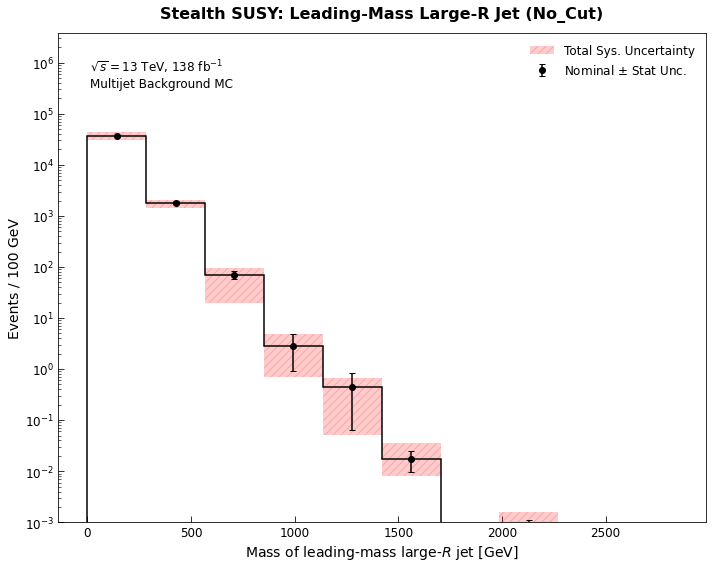

Total events loaded: 6
Calculating uncertainty envelope across 26 systematic variations...


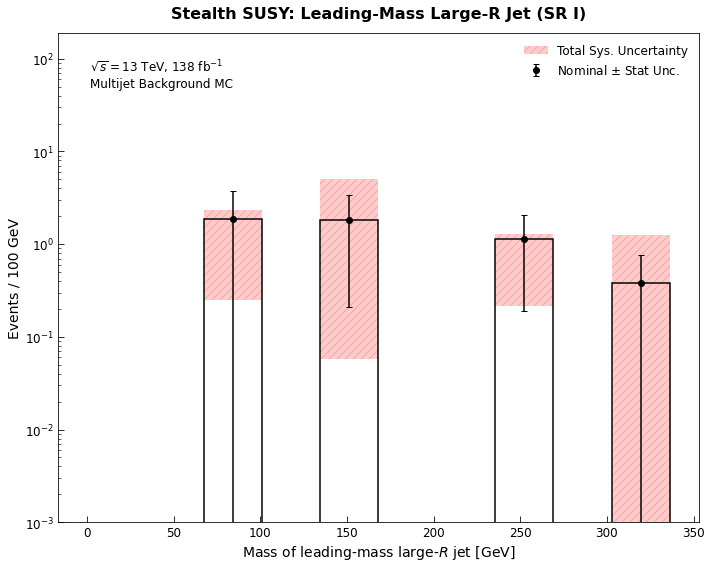

Total events loaded: 188
Calculating uncertainty envelope across 26 systematic variations...


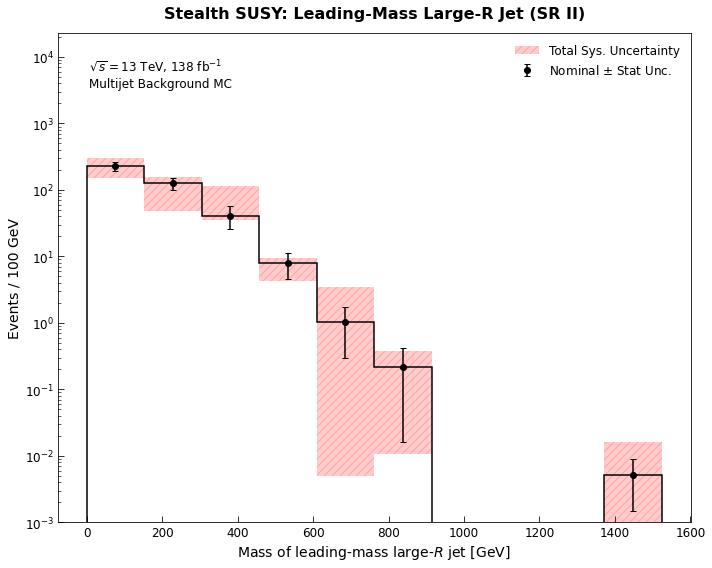

In [17]:
df_nocut = load_region_data("MC_Events/No_Cut")
df_sr1 = load_region_data("MC_Events/SR_I")
df_sr2 = load_region_data("MC_Events/SR_II")

plot_dataframe(df_nocut, "No_Cut")
plot_dataframe(df_sr1, "SR I")
plot_dataframe(df_sr2, "SR II")